# Sport and Health: Predicting Daily Calories Burned from Fitbit Activity Data

**CPE393 – Introduction to Data Science with Python — Final Group Project**

**Group:** IUTO &nbsp;|&nbsp; **Members:** Leni Chabilan · Romain Mechain · Kylian Riberou

---

## Project summary

This project builds a **regression** model that predicts the number of
**calories a person burns in a day** from their recorded physical activity
(steps, distance, and active minutes at different intensities).

We use the **FitBit Fitness Tracker** dataset: real data voluntarily shared by
33 Fitbit users through Amazon Mechanical Turk in 2016 (public domain, CC0).
Unlike a synthetic dataset, these are genuine measurements, so the
relationships we find are physiologically meaningful — while still being noisy
enough to make the problem realistic rather than trivial.

Because each user contributes many daily records (panel data), we split the
data **by user** so that no individual appears in both the training and test
sets, preventing data leakage.

## 1. Setup and imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
print("Libraries imported.")

Libraries imported.


## 2. Problem definition

**Goal.** Predict `Calories` (total calories burned in a day) from a person's
daily activity metrics.

**Why it matters.** Fitness trackers estimate calorie expenditure using
proprietary formulas that also rely on personal data (age, weight, heart rate).
By modelling calories from *activity alone*, we can measure **how much of daily
energy expenditure is explained by movement** — and, just as importantly, how
much is not. This is a genuine regression problem with real, noisy human data.

**Target variable:** `Calories` (continuous).
**Task type:** Regression.
**Evaluation:** MAE, RMSE, and R2, reported on users unseen during training.

## 3. Dataset description

* **Source:** FitBit Fitness Tracker Data — Kaggle (`arashnic/fitbit`),
  originally collected by Furberg et al. (2016), distributed under CC0.
* **File used:** `dailyActivity_merged.csv` — one row per user per day.
* **Unit of observation:** a single day for a single participant.
* **License:** Public Domain (CC0).

In [2]:
df = pd.read_csv("data/fitbit/dailyActivity_merged.csv")
df["ActivityDate"] = pd.to_datetime(df["ActivityDate"])

print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
print(f"Unique participants: {df['Id'].nunique()}")
print(f"Date range: {df['ActivityDate'].min().date()} -> {df['ActivityDate'].max().date()}")
df.head()

Rows: 940   Columns: 15
Unique participants: 33
Date range: 2016-04-12 -> 2016-05-12


,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [3]:
# Column overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        940 non-null    int64         
 1   ActivityDate              940 non-null    datetime64[us]
 2   TotalSteps                940 non-null    int64         
 3   TotalDistance             940 non-null    float64       
 4   TrackerDistance           940 non-null    float64       
 5   LoggedActivitiesDistance  940 non-null    float64       
 6   VeryActiveDistance        940 non-null    float64       
 7   ModeratelyActiveDistance  940 non-null    float64       
 8   LightActiveDistance       940 non-null    float64       
 9   SedentaryActiveDistance   940 non-null    float64       
 10  VeryActiveMinutes         940 non-null    int64         
 11  FairlyActiveMinutes       940 non-null    int64         
 12  LightlyActiveMinutes      940 non

## 4. Preprocessing and cleaning

We audit the data for missing values, duplicates, and — most importantly for
wearable data — **days when the device was clearly not worn**, which masquerade
as real "zero activity" days.

In [4]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0] if df.isna().sum().sum() else "None")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
None

Duplicate rows: 0


### 4.1 Detecting non-wear days

Three signals indicate the tracker was not really worn / recording a valid day:

* `TotalSteps == 0` (no steps recorded all day),
* `Calories == 0` (physically impossible for a living person),
* `SedentaryMinutes == 1440` (the full 24 h logged as sedentary).

These are **measurement artifacts**, not genuine rest days, so we remove them —
keeping them would teach the model that "no activity -> still ~some calories"
from days that were never really measured.

In [5]:
before = len(df)
n_zero_steps = (df["TotalSteps"] == 0).sum()
n_zero_cal   = (df["Calories"] == 0).sum()
n_full_sed   = (df["SedentaryMinutes"] >= 1440).sum()
print(f"Days with 0 steps           : {n_zero_steps}")
print(f"Days with 0 calories        : {n_zero_cal}")
print(f"Days fully sedentary (1440m) : {n_full_sed}")

# Remove non-wear / invalid days
df_clean = df[(df["TotalSteps"] > 0) &
              (df["Calories"] > 0) &
              (df["SedentaryMinutes"] < 1440)].copy()

print(f"\nRows: {before} -> {len(df_clean)} ({before - len(df_clean)} removed, "
      f"{(before-len(df_clean))/before*100:.1f}%)")
print(f"Participants retained: {df_clean['Id'].nunique()} / {df['Id'].nunique()}")

Days with 0 steps           : 77
Days with 0 calories        : 4
Days fully sedentary (1440m) : 79

Rows: 940 -> 856 (84 removed, 8.9%)
Participants retained: 33 / 33


### 4.2 Redundant columns

Fitbit exports several overlapping distance columns. `TotalDistance` and
`TrackerDistance` are nearly identical (the tracker distance plus any manually
logged distance), and the per-intensity *distance* columns duplicate
information already carried by the per-intensity *minute* columns. To avoid
multicollinearity we keep a compact, non-redundant feature set based on steps
and active-minute buckets, and drop the duplicated distance breakdowns.

In [6]:
# Quick check of the redundancy between the two distance columns
corr_dist = df_clean["TotalDistance"].corr(df_clean["TrackerDistance"])
print(f"corr(TotalDistance, TrackerDistance) = {corr_dist:.3f}")

drop_cols = ["TrackerDistance", "LoggedActivitiesDistance",
             "VeryActiveDistance", "ModeratelyActiveDistance",
             "LightActiveDistance", "SedentaryActiveDistance"]
df_clean = df_clean.drop(columns=drop_cols)
print("Remaining columns:", df_clean.columns.tolist())

corr(TotalDistance, TrackerDistance) = 0.999
Remaining columns: ['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']


## 5. Exploratory Data Analysis

In [7]:
df_clean[["Calories", "TotalSteps", "TotalDistance", "VeryActiveMinutes",
          "FairlyActiveMinutes", "LightlyActiveMinutes",
          "SedentaryMinutes"]].describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
Calories,856.0,2358.6,704.3,52.0,1854.0,2214.5,2830.5,4900.0
TotalSteps,856.0,8328.7,4754.9,4.0,4924.5,8053.5,11100.2,36019.0
TotalDistance,856.0,6.0,3.7,0.0,3.4,5.6,7.9,28.0
VeryActiveMinutes,856.0,23.2,33.7,0.0,0.0,7.0,36.0,210.0
FairlyActiveMinutes,856.0,14.9,20.5,0.0,0.0,8.0,21.0,143.0
LightlyActiveMinutes,856.0,211.7,95.3,1.0,148.0,209.5,272.0,518.0
SedentaryMinutes,856.0,951.8,278.0,0.0,720.8,1019.5,1187.2,1439.0


### 5.1 Target distribution

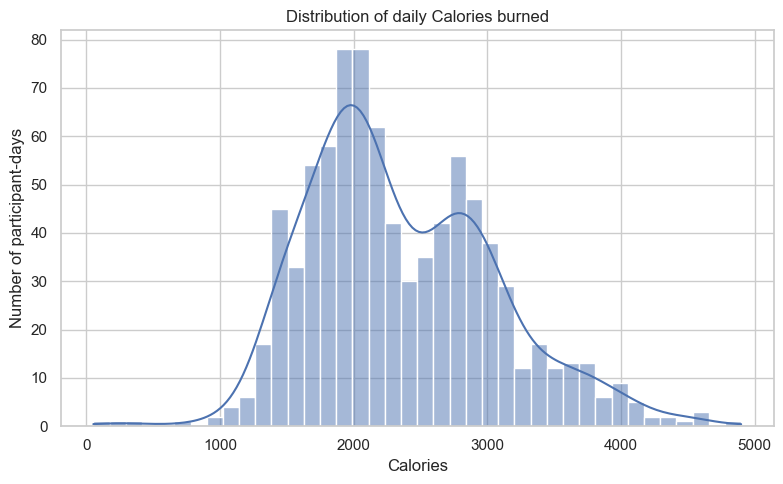

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Calories"], kde=True, bins=40, color="#4C72B0")
plt.title("Distribution of daily Calories burned")
plt.xlabel("Calories"); plt.ylabel("Number of participant-days")
plt.tight_layout(); plt.show()

The target is roughly bell-shaped, centred around ~2,300 kcal/day, with a mild
right tail from very active days. No transformation is needed.

### 5.2 Correlation with the target

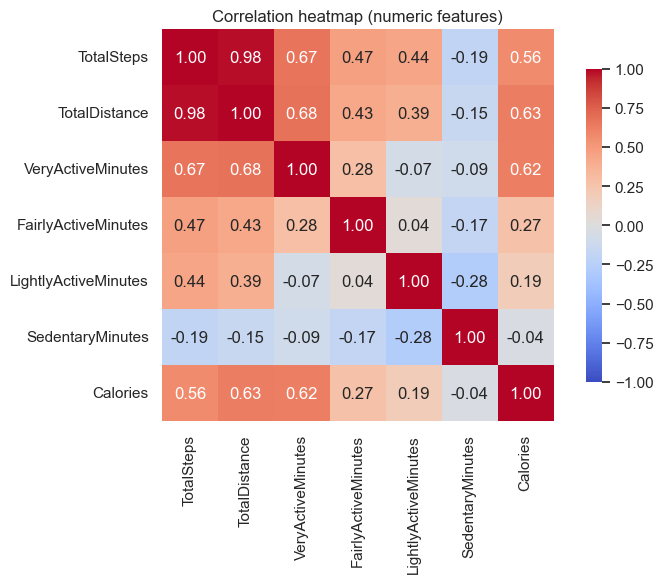

Correlation with Calories:
TotalDistance           0.626
VeryActiveMinutes       0.617
TotalSteps              0.563
FairlyActiveMinutes     0.269
LightlyActiveMinutes    0.194
SedentaryMinutes       -0.038
Name: Calories, dtype: float64


In [9]:
num_cols = df_clean.select_dtypes(include=[np.number]).drop(columns=["Id"])
corr = num_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .8})
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout(); plt.show()

print("Correlation with Calories:")
print(corr["Calories"].drop("Calories").sort_values(ascending=False).round(3))

**Insight.** Calories correlate most strongly with `TotalDistance` and
`TotalSteps` (~0.6) and with `VeryActiveMinutes` (~0.6). `SedentaryMinutes` is
slightly *negatively* related. These moderate correlations are exactly what we
expect from real data: movement drives a large part of calorie burn, but not
all of it (body weight, age and basal metabolism — absent here — matter too).

### 5.3 Activity vs calories

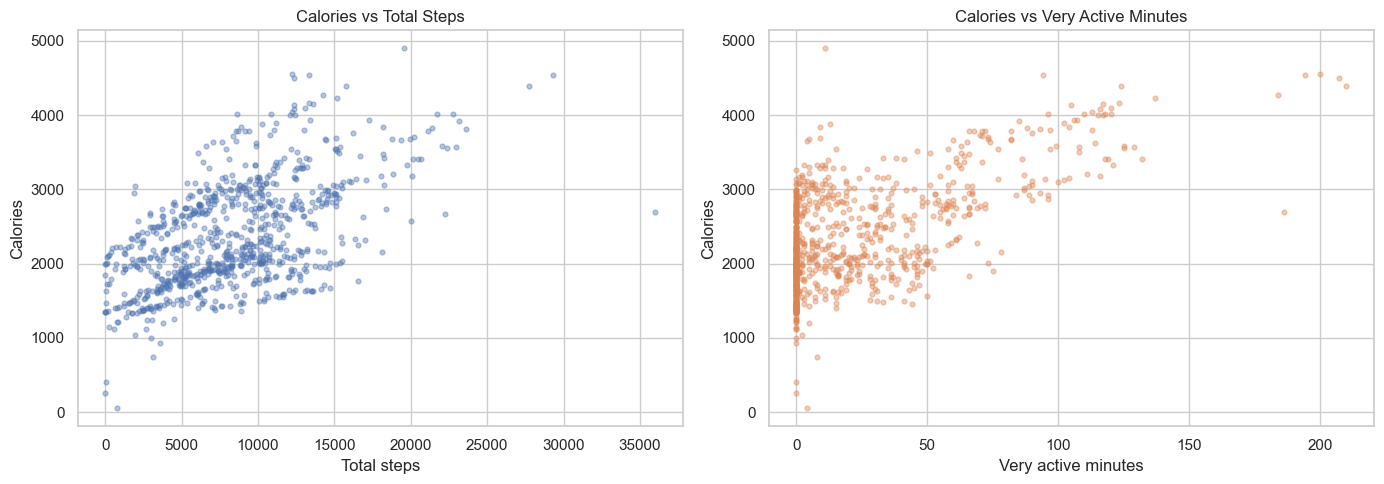

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df_clean["TotalSteps"], df_clean["Calories"],
                s=12, alpha=0.4, color="#4C72B0")
axes[0].set_title("Calories vs Total Steps")
axes[0].set_xlabel("Total steps"); axes[0].set_ylabel("Calories")

axes[1].scatter(df_clean["VeryActiveMinutes"], df_clean["Calories"],
                s=12, alpha=0.4, color="#DD8452")
axes[1].set_title("Calories vs Very Active Minutes")
axes[1].set_xlabel("Very active minutes"); axes[1].set_ylabel("Calories")
plt.tight_layout(); plt.show()

Both plots show a clear positive trend with substantial scatter — more
activity means more calories on average, but two people with the same step
count can still differ by hundreds of calories, reflecting the personal factors
the dataset does not capture.

## 6. Feature engineering

We derive a few interpretable features from the raw activity columns:

* **`TotalActiveMinutes`** = very + fairly + lightly active minutes — total time
  spent moving, a natural driver of energy expenditure.
* **`ActiveRatio`** = active minutes / (active + sedentary) — *how much* of the
  tracked day was spent active, independent of how long the device was worn.
* **`StepsPerActiveMinute`** = intensity proxy (steps per active minute).

In [11]:
df_clean["TotalActiveMinutes"] = (df_clean["VeryActiveMinutes"]
                                  + df_clean["FairlyActiveMinutes"]
                                  + df_clean["LightlyActiveMinutes"])

df_clean["ActiveRatio"] = (df_clean["TotalActiveMinutes"] /
    (df_clean["TotalActiveMinutes"] + df_clean["SedentaryMinutes"]))

df_clean["StepsPerActiveMinute"] = (df_clean["TotalSteps"] /
    df_clean["TotalActiveMinutes"].replace(0, np.nan)).fillna(0)

new_feats = ["TotalActiveMinutes", "ActiveRatio", "StepsPerActiveMinute"]
print("New features created:", new_feats)
print(df_clean[new_feats + ["Calories"]].corr()["Calories"].round(3))

New features created: ['TotalActiveMinutes', 'ActiveRatio', 'StepsPerActiveMinute']
TotalActiveMinutes      0.433
ActiveRatio             0.237
StepsPerActiveMinute    0.351
Calories                1.000
Name: Calories, dtype: float64


## 7. Train/test split — by participant

Each participant contributes many days. A random row-level split would let the
same person appear in both train and test, so the model could learn individual
baselines instead of a general relationship — a form of **data leakage**. We use
`GroupShuffleSplit` on `Id` so that whole participants (not rows) are assigned to
train or test.

In [12]:
feature_cols = ["TotalSteps", "TotalDistance",
                "VeryActiveMinutes", "FairlyActiveMinutes",
                "LightlyActiveMinutes", "SedentaryMinutes",
                "TotalActiveMinutes", "ActiveRatio", "StepsPerActiveMinute"]

X = df_clean[feature_cols]
y = df_clean["Calories"]
groups = df_clean["Id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_users = set(groups.iloc[train_idx]); test_users = set(groups.iloc[test_idx])
print(f"Train: {len(X_train)} rows / {len(train_users)} users")
print(f"Test : {len(X_test)} rows / {len(test_users)} users")
print(f"User overlap: {len(train_users & test_users)} "
      f"({'no leakage' if not (train_users & test_users) else 'LEAKAGE'})")

Train: 666 rows / 26 users
Test : 190 rows / 7 users
User overlap: 0 (no leakage)


## 8. Model training

We train three regression models of increasing flexibility:

1. **Linear Regression** — interpretable baseline.
2. **Decision Tree** — captures non-linear thresholds (depth-limited).
3. **Random Forest** — ensemble, usually the most accurate and robust.

In [13]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=6, min_samples_leaf=20,
                                           random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10,
                                           min_samples_leaf=5,
                                           random_state=RANDOM_STATE, n_jobs=-1),
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"{name} trained.")

Linear Regression trained.
Decision Tree trained.
Random Forest trained.


## 9. Evaluation

Regression metrics on the held-out **unseen users**: MAE and RMSE (in
calories, lower is better) and R2 (share of variance explained, higher is
better).

In [14]:
rows = []
for name, preds in predictions.items():
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    rows.append({"Model": name, "MAE": round(mae, 1),
                 "RMSE": round(rmse, 1), "R2": round(r2, 3)})

results = pd.DataFrame(rows).sort_values("R2", ascending=False).reset_index(drop=True)
results

,Model,MAE,RMSE,R2
0,Linear Regression,357.5,422.5,0.411
1,Random Forest,349.4,432.5,0.383
2,Decision Tree,447.0,539.7,0.039


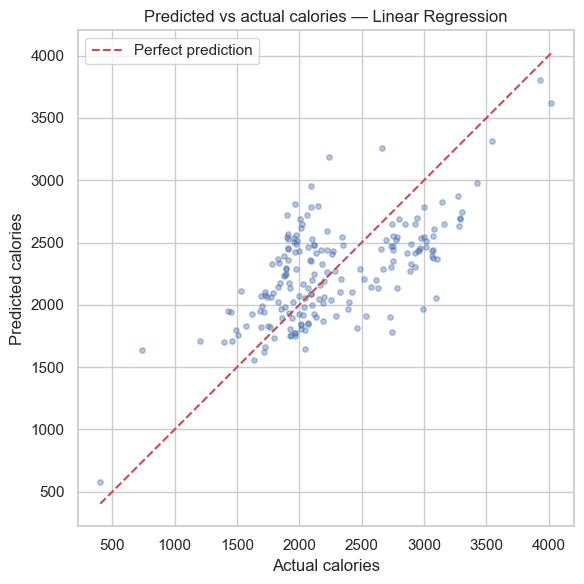

In [15]:
# Predicted vs actual for the best model
best_name = results.iloc[0]["Model"]
best_preds = predictions[best_name]

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_preds, s=15, alpha=0.4, color="#4C72B0")
lo, hi = y_test.min(), y_test.max()
plt.plot([lo, hi], [lo, hi], "r--", lw=1.5, label="Perfect prediction")
plt.title(f"Predicted vs actual calories — {best_name}")
plt.xlabel("Actual calories"); plt.ylabel("Predicted calories")
plt.legend(); plt.tight_layout(); plt.show()

### 9.1 Feature importance

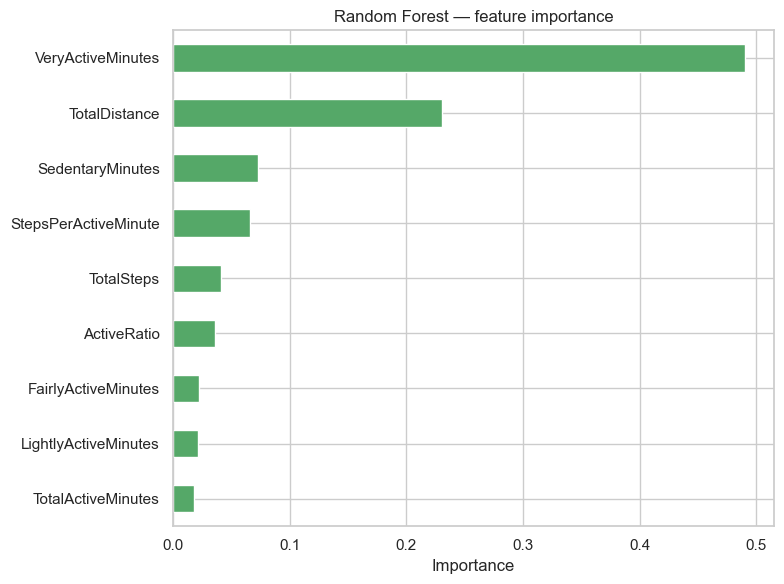

VeryActiveMinutes       0.491
TotalDistance           0.230
SedentaryMinutes        0.073
StepsPerActiveMinute    0.066
TotalSteps              0.042
ActiveRatio             0.036
FairlyActiveMinutes     0.023
LightlyActiveMinutes    0.021
TotalActiveMinutes      0.018
dtype: float64


In [16]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values()

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="#55A868")
plt.title("Random Forest — feature importance")
plt.xlabel("Importance"); plt.tight_layout(); plt.show()

print(importances.sort_values(ascending=False).round(3))

**Interpretation.** The distance / step and active-minute features carry most
of the predictive weight, consistent with the correlation analysis. The models
reach a *moderate* R2: activity meaningfully predicts calories, but a large
share of variance stays unexplained because body weight, age and basal
metabolic rate — the biggest real drivers of calorie burn — are simply not in
this dataset. This is an honest ceiling, not a failure of the models.

## 10. Responsible AI practices

* **Privacy / consent.** The data was shared voluntarily and anonymised (users
  are integer IDs). It nonetheless reveals intimate behaviour — daily movement,
  sleep — so it should never be re-identified or used to profile individuals.
* **Sampling bias.** Only 33 self-selected Mechanical Turk users in 2016. They
  are not representative of the general population (age, country, fitness level
  unknown), so the model must **not** be presented as universally valid.
* **Avoiding data leakage.** We split by participant, not by row, so reported
  scores reflect generalisation to *new people*.
* **Honest performance.** We report a moderate R2 and explain *why* (missing
  personal variables) rather than tuning for an impressive-looking number.
* **Non-wear artifacts.** We removed zero-step / zero-calorie / fully-sedentary
  days so the model is not trained on non-measurements.
* **Misuse risk.** Calorie-burn estimates should not drive medical, dietary, or
  insurance decisions; they are approximate and population-limited.

## 11. Conclusion and future work

**Findings.** Using only daily activity metrics, our models predict daily
calories burned with moderate accuracy (Random Forest performing best), with
step count, distance and very-active minutes as the strongest drivers. The
substantial remaining error reflects genuinely missing information (body
weight, age, heart rate) rather than a modelling flaw.

**What we learned.** Real-world wearable data needs careful cleaning
(non-wear days), a leakage-safe participant-level split, and honest reporting of
what a limited feature set can and cannot explain.

**Future work.**
* Merge `sleepDay_merged.csv` to add sleep as a feature (covers 24/33 users).
* Obtain body weight / age to close the biggest gap in the feature set.
* Try gradient boosting and cross-validated hyperparameter tuning.
* Model at the per-user level to study individual calorie-burn profiles.